# train_data exploration

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from Src.train_data_modules import *

In [ ]:
train_data, train_target = load_data()

## Exploration

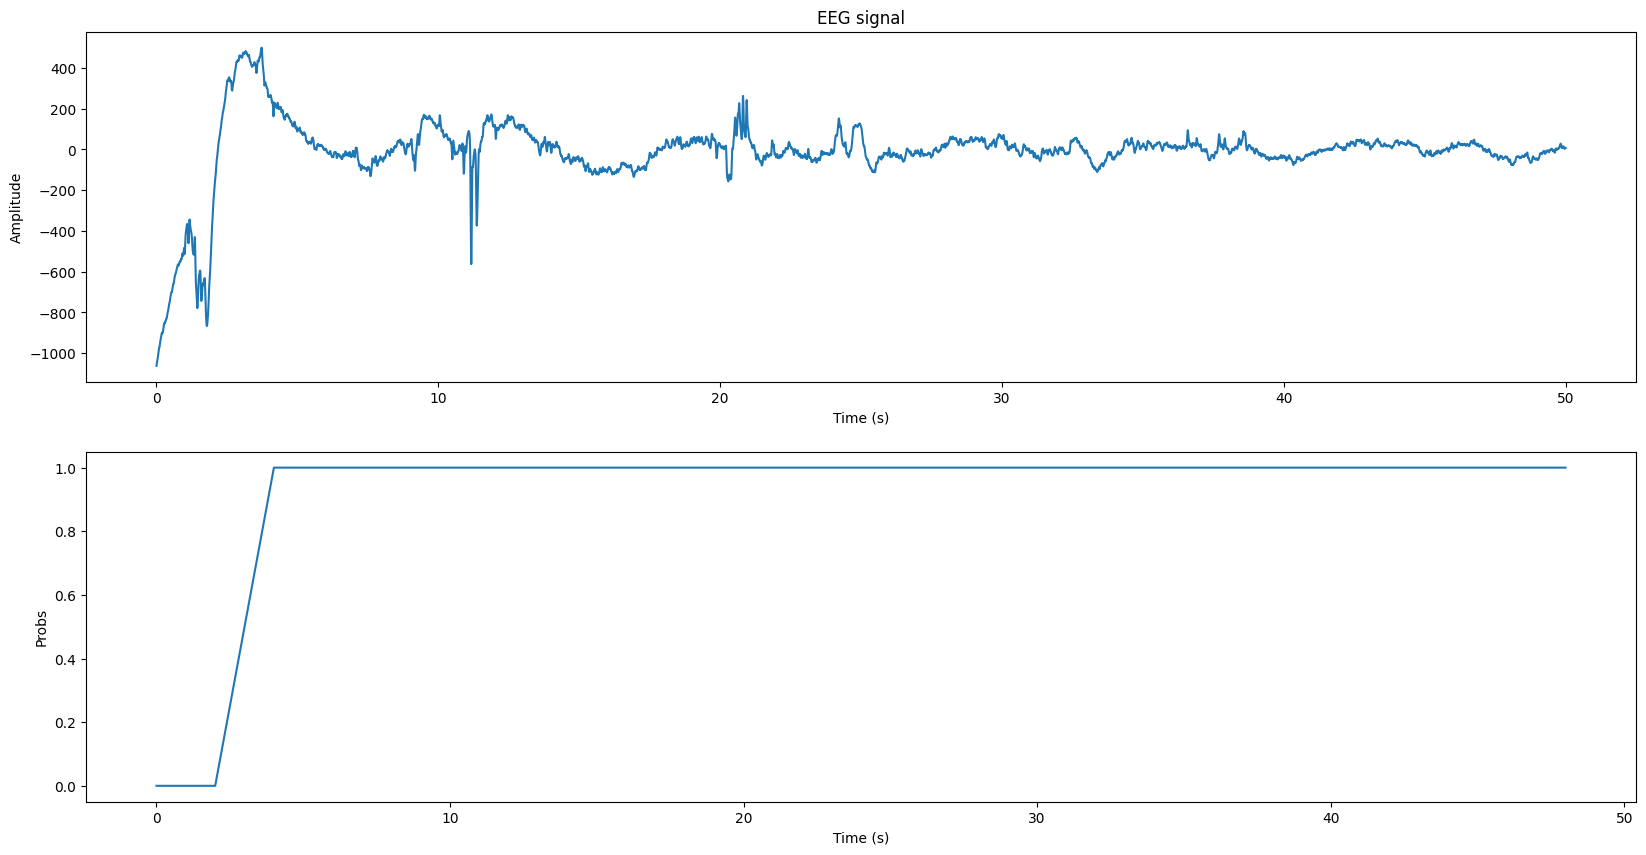

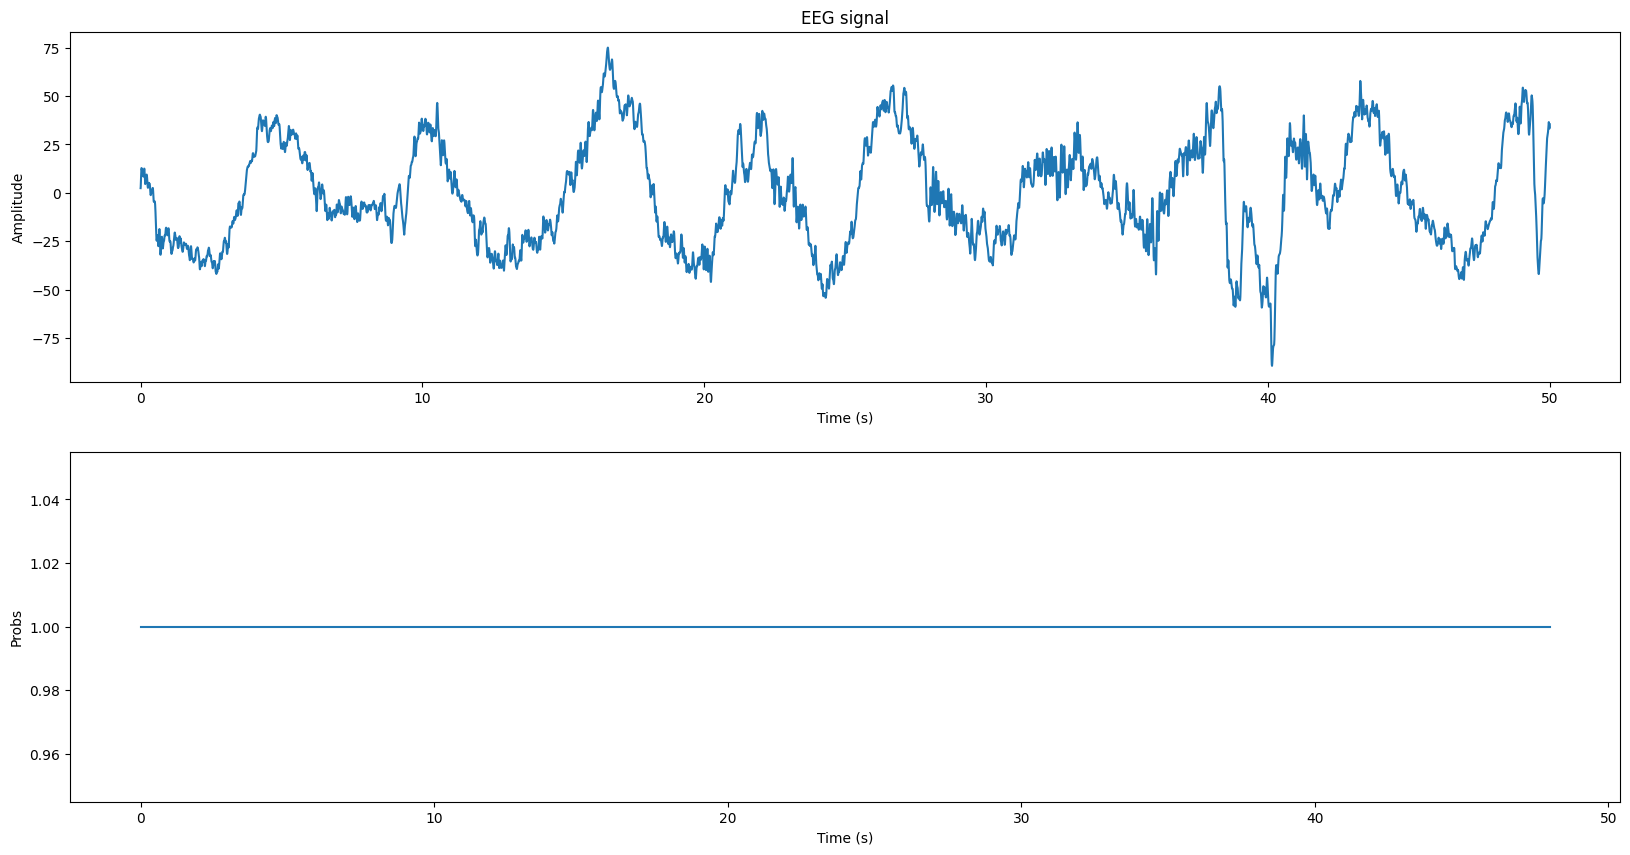

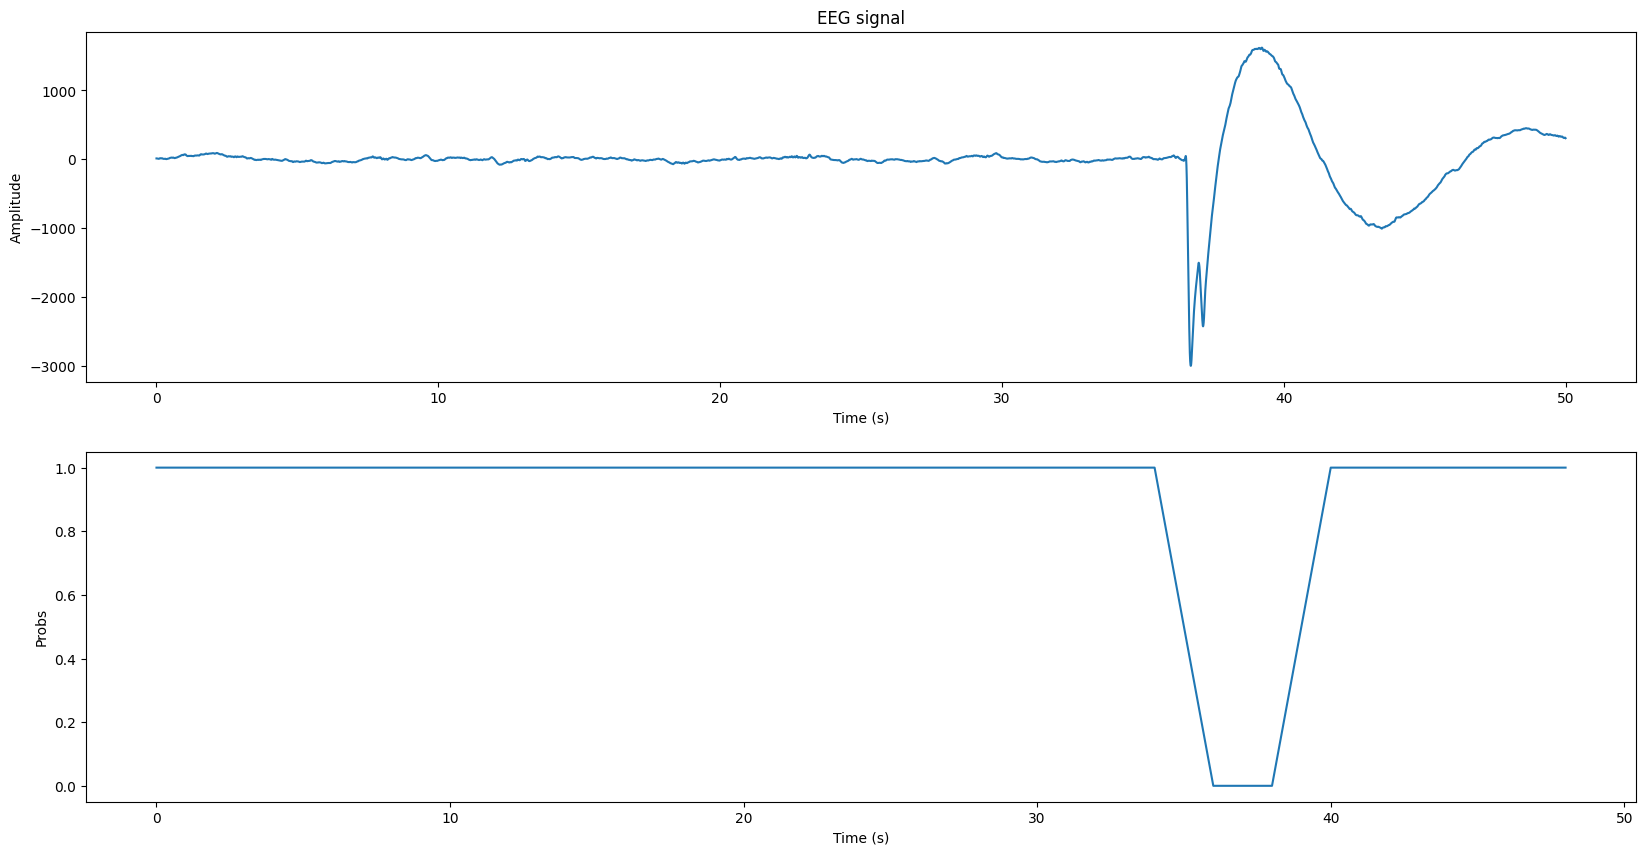

In [4]:
filtered_train_data = butter_bandpass_filter(train_data,0.1,18,250,4)
# We plot three spans and associated labels from the recording

plot_predictions_and_signal(train_target,filtered_train_data,start_time = 300, stop_time = 350, train_data_sampling_rate = 250,train_target_duration = 2 ,channel_to_plot = 2)
plot_predictions_and_signal(train_target,filtered_train_data,start_time = 1000, stop_time = 1050, train_data_sampling_rate = 250,train_target_duration = 2 ,channel_to_plot = 2)
plot_predictions_and_signal(train_target,filtered_train_data,start_time = 3000, stop_time = 3050, train_data_sampling_rate = 250,train_target_duration = 2 ,channel_to_plot = 2)

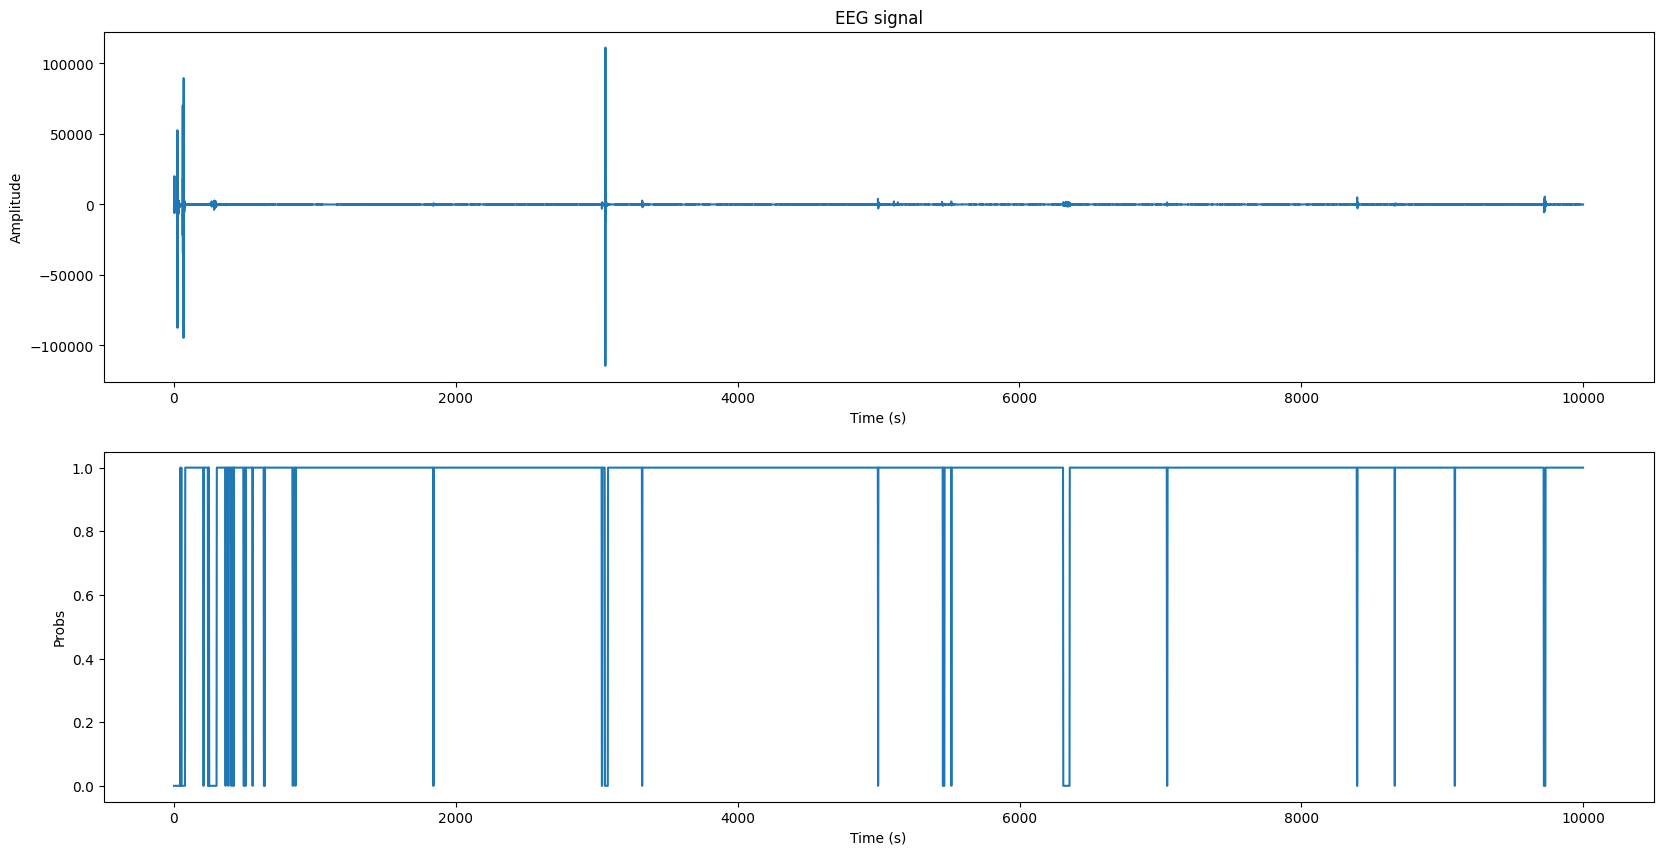

In [18]:
plot_predictions_and_signal(train_target,filtered_train_data,start_time = 0, stop_time = 10000, train_data_sampling_rate = 250,train_target_duration = 2 ,channel_to_plot = 2)

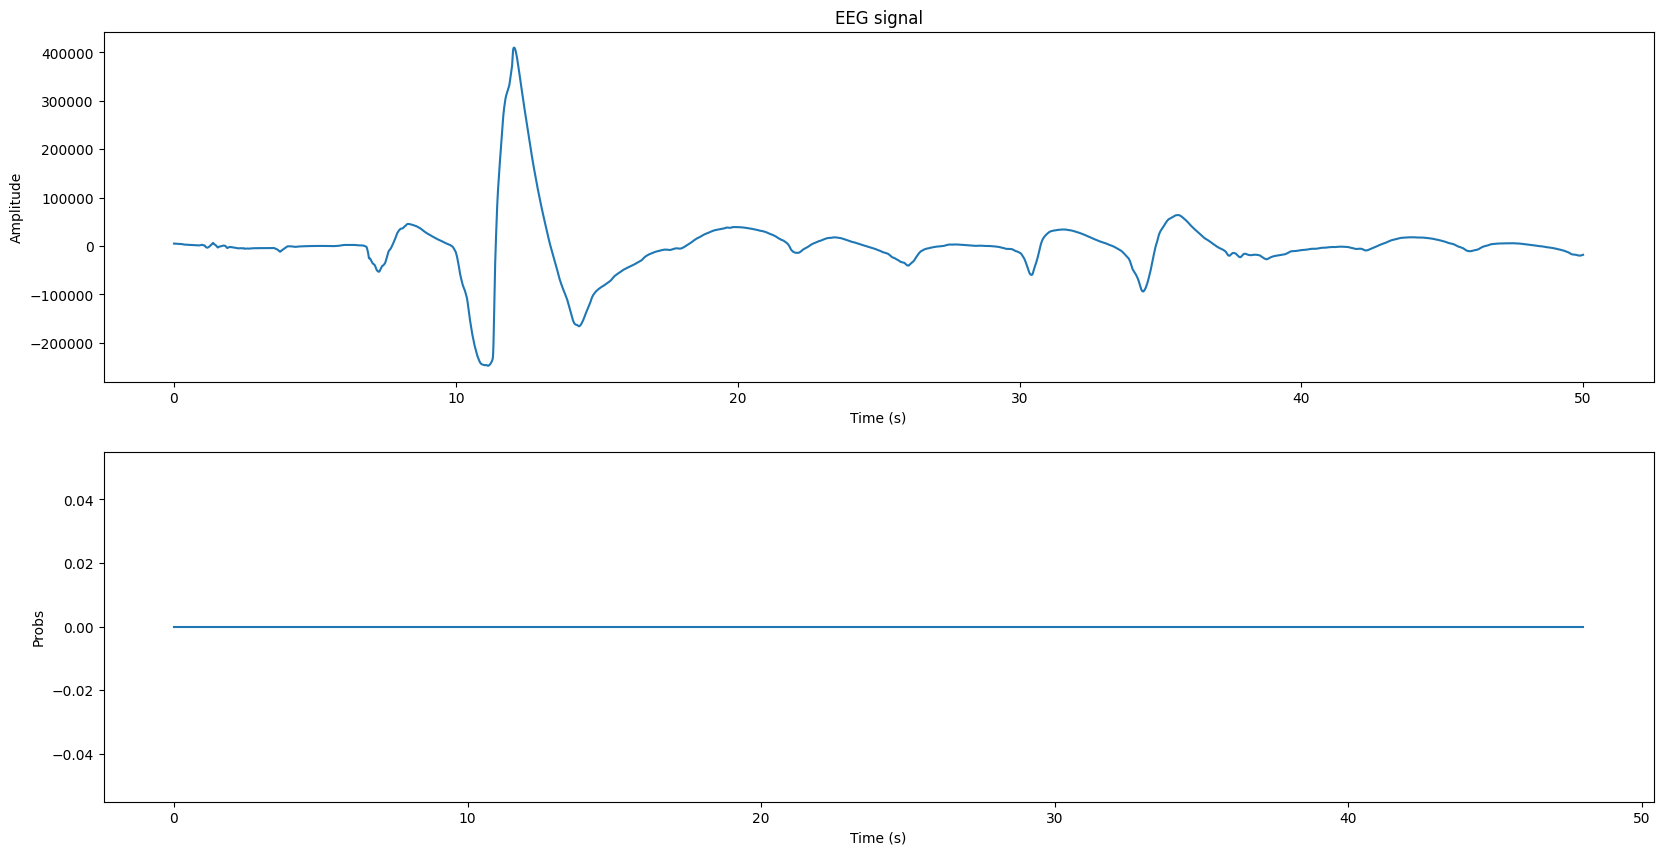

In [22]:
plot_predictions_and_signal(train_target,filtered_train_data,start_time = 300, stop_time = 350, train_data_sampling_rate = 250,train_target_duration = 2 ,channel_to_plot = 3)

In [16]:
len(train_data[0])/250

20929.456

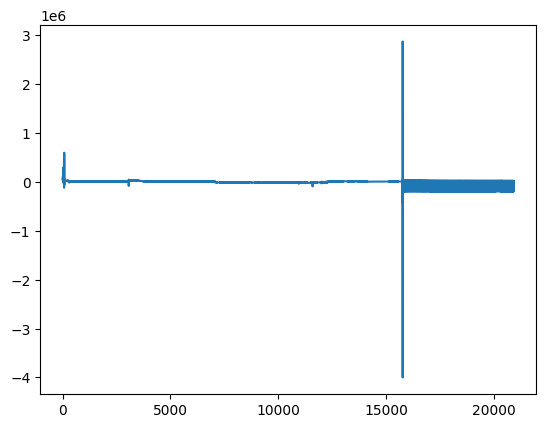

In [21]:
plt.plot(np.arange(len(train_data[0])) /250, train_data[0])

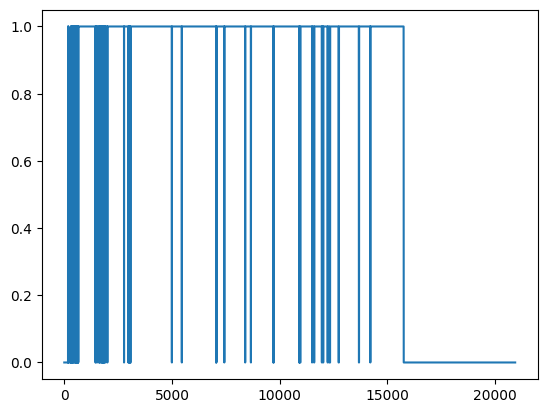

In [20]:
plt.plot(np.arange(len(train_target[0])) * 2, train_target[0])

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from mne.time_frequency import tfr_array_multitaper

# Paramètres du signal
sampling_rate = 250  # Fréquence d'échantillonnage en Hz
n_cycles = 1  # Nombre de cycles par fréquence

n_channels = 5  # 5 canaux
n_times = 500 # Points par époque pour 2 secondes à 250 Hz
n_epochs = train_data.shape[1] // n_times  # Nombre total d'époques possibles

# Redimensionner les données, en ignorant les points restants
eeg_train_data = train_data[:, :n_epochs * n_times].reshape(n_epochs, n_channels, n_times)

eeg_train_data = eeg_train_data[:1000]

# Calculer le spectrogramme multitaper
frequencies = np.linspace(1, 25, 25)
power = tfr_array_multitaper(eeg_train_data, sfreq=sampling_rate,
                             freqs=frequencies, n_cycles=n_cycles, output='power')

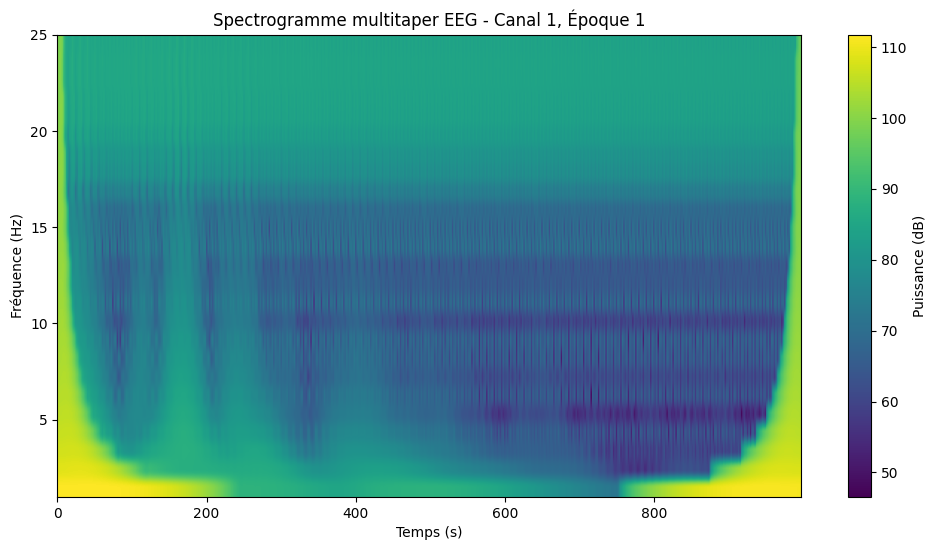

In [24]:
power_x = power[:10]
# Convertir la puissance en dB
power_dB = 10 * np.log10(power_x)

# Afficher le spectrogramme pour le premier canal (index 0) et la première époque (index 0)
time_axis = np.arange(power_x.shape[3]) * (power_x.shape[3] / sampling_rate)  # Temps en secondes
plt.figure(figsize=(12, 6))
plt.imshow(power_dB[0, 0], aspect='auto', origin='lower',  # Canal 0, Époque 0
           extent=[0, time_axis[-1], frequencies[0], frequencies[-1]],
           cmap='viridis')
plt.colorbar(label='Puissance (dB)')
plt.xlabel("Temps (s)")
plt.ylabel("Fréquence (Hz)")
plt.title("Spectrogramme multitaper EEG - Canal 1, Époque 1")
plt.show()